In [ ]:
# SCATTER
# COLOR

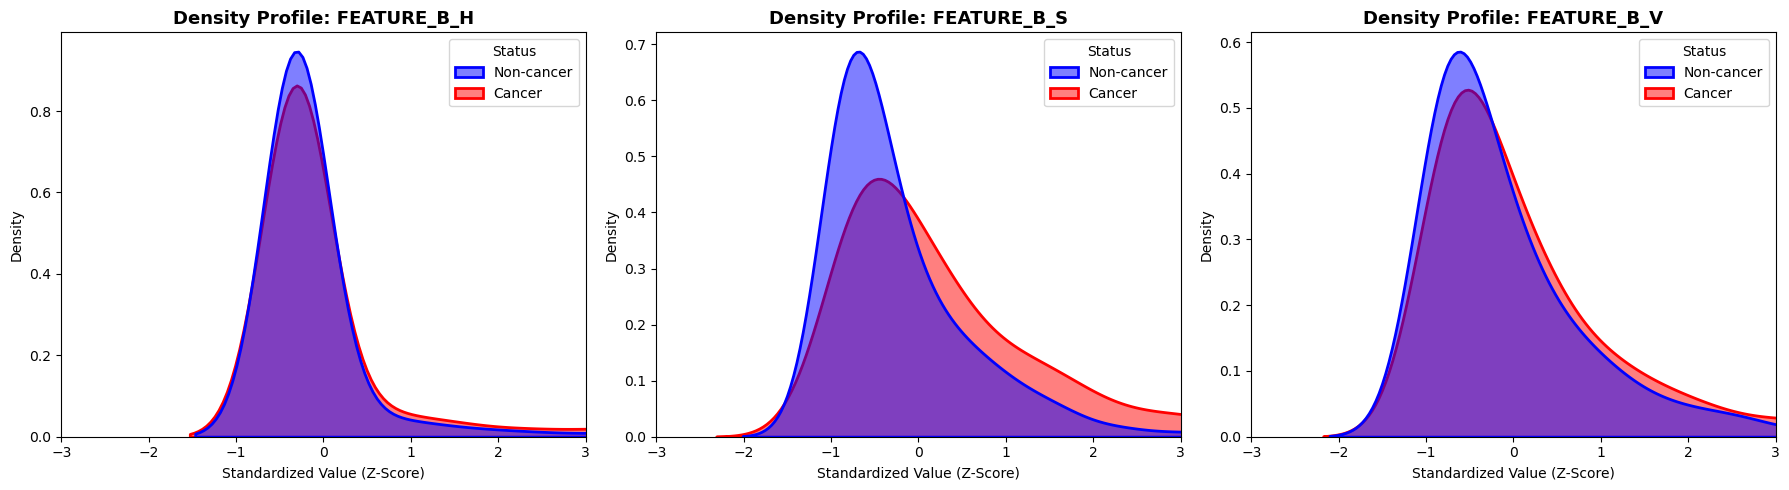

Grid image saved: hsv_variance_density_grid.png


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Setup
df = pd.read_csv('../data/features.csv')
features_to_plot = ['FEATURE_B_H', 'FEATURE_B_S', 'FEATURE_B_V']
output_folder = "../result/figures"

# 2. Data Cleaning & Scaling
df['Cancerous'] = df['Cancerous'].astype(str)

for f in features_to_plot:
    lower, upper = df[f].quantile([0.01, 0.99])
    df = df[(df[f] >= lower) & (df[f] <= upper)]

scaler = StandardScaler()
df[features_to_plot] = scaler.fit_transform(df[features_to_plot])

# 3. Create Grid Plot (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["blue", "red"]

for i, feature in enumerate(features_to_plot):
    ax = sns.kdeplot(
        data=df, x=feature, hue="Cancerous", fill=True,
        common_norm=False, palette=colors,
        hue_order=["0", "1"], alpha=0.5, linewidth=2, bw_adjust=1.5,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Density Profile: {feature}", fontsize=13, fontweight='bold')
    axes[i].set_xlim(-3, 3)
    axes[i].set_xlabel("Standardized Value (Z-Score)")
    
    # Legend Fix (Matches your previous logic)
    legend = axes[i].get_legend()
    if legend:
        legend.set_title("Status")
        for t, l in zip(legend.get_texts(), ["Non-cancer", "Cancer"]):
            t.set_text(l)

plt.tight_layout()
plt.savefig(f"{output_folder}/hsv_variance_density_grid.png", dpi=300)
plt.show()

print("Grid image saved: hsv_variance_density_grid.png")

Saved: ../result/figures/border_asymmetry_fitted_2d.png


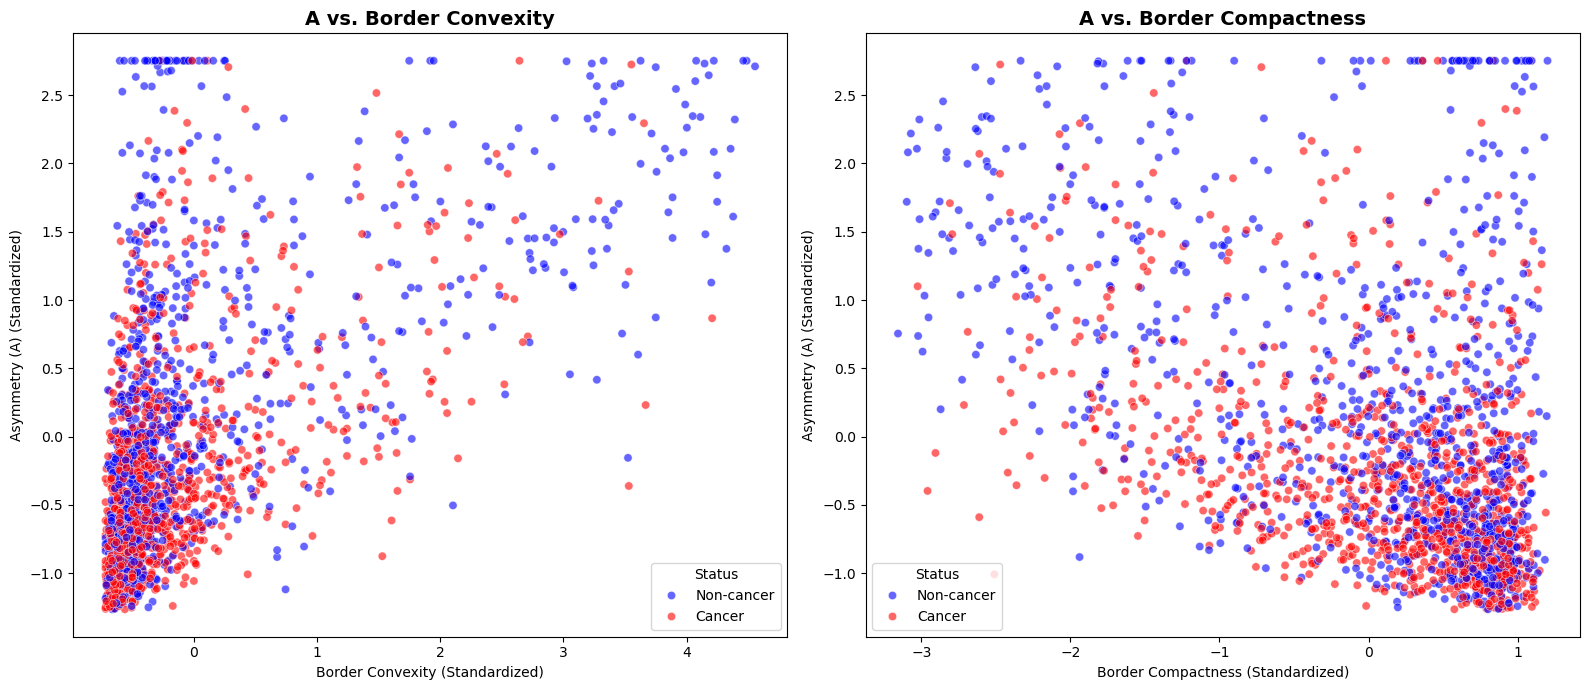

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# --- 1. Setup ---
output_folder = "../result/figures"
os.makedirs(output_folder, exist_ok=True)

# --- 2. Create Figure (1 row, 2 columns) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ["blue", "red"]

# --- PLOT 1: Asymmetry vs. Convexity ---
sns.scatterplot(
    data=df, 
    x="FEATURE_BORDER_CONVEXITY", 
    y="FEATURE_A", 
    hue="Cancerous", 
    palette=colors,
    hue_order=["0", "1"],
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    ax=axes[0]
)
axes[0].set_title("A vs. Border Convexity", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Border Convexity (Standardized)")
axes[0].set_ylabel("Asymmetry (A) (Standardized)")
# Auto-fit logic
axes[0].autoscale(enable=True, axis='both', tight=False)

# --- PLOT 2: Asymmetry vs. Compactness ---
sns.scatterplot(
    data=df, 
    x="FEATURE_BORDER_COMPACTNESS", 
    y="FEATURE_A", 
    hue="Cancerous", 
    palette=colors,
    hue_order=["0", "1"],
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    ax=axes[1]
)
axes[1].set_title("A vs. Border Compactness", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Border Compactness (Standardized)")
axes[1].set_ylabel("Asymmetry (A) (Standardized)")
# Auto-fit logic
axes[1].autoscale(enable=True, axis='both', tight=False)

# --- 3. Legend & Layout Fixes ---
for ax in axes:
    legend = ax.get_legend()
    if legend:
        legend.set_title("Status")
        for t, l in zip(legend.get_texts(), ["Non-cancer", "Cancer"]):
            t.set_text(l)

plt.tight_layout()

# --- 4. Saving ---
save_path = f"{output_folder}/border_asymmetry_fitted_2d.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()